In [1]:
!pip install opencv-python tensorflow keras matplotlib numpy scikit-learn seaborn

In [2]:
import os
import json
import difflib
import face_recognition
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint

In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
from sklearn.model_selection import train_test_split

TensorFlow version: 2.21.0
GPU Available: []


In [4]:
def video_to_frames(video_path, max_frames=10): # <-- Buraya max_frames=20 ekledik
    vidcap = cv2.VideoCapture(video_path)
    if not vidcap.isOpened():
        print(f"Video açılamadı: {video_path}")
        return []

    # Toplam kare sayısını al
    total_frames = int(vidcap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Kaç karede bir atlayacağımızı hesapla
    skip_interval = max(1, total_frames // max_frames)
    
    frames = []
    count = 0
    while len(frames) < max_frames:
        vidcap.set(cv2.CAP_PROP_POS_FRAMES, count * skip_interval)
        success, image = vidcap.read()
        
        if not success:
            break
            
        if image is not None and len(image.shape) == 3:
            # Görüntüyü RGB'ye çevirip listeye ekle
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            frames.append(rgb_image)
        
        count += 1
        if (count * skip_interval) >= total_frames:
            break

    vidcap.release()
    return frames

# def video_to_frames(video_path,max_frames=20):
#     # cv2.VideoCapture ile video dosyasını aç
#     vidcap = cv2.VideoCapture(video_path)

#     # Video açılamazsa hata mesajı yaz ve boş liste döndür
#     if not vidcap.isOpened():
#         print(f"Video açılamadı: {video_path}")
#         return []

#     # İlk kareyi oku
#     success, image = vidcap.read()
#     frames = []

#     # Başarılı olduğu sürece döngü
#     while success:
#         # Görüntü bozuk veya uygun formatta değilse atla
#         if image is None or len(image.shape) != 3:
#             print(f"Bozuk kare atlandı: {image.shape if image is not None else 'None'}")
#         else:
#             # Görüntü başarıyla okundu, boyut ve tipi yazdır
#             print(f"Görüntü alındı: {image.shape}, dtype: {image.dtype}")
            
#             # BGR'den RGB'ye çevir
#             rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
#             # Kareleri listeye ekle
#             frames.append(rgb_image)

#         # Sonraki kareyi oku
#         success, image = vidcap.read()


#     # Toplam kare sayısını yazdır    

#     if len(frames) == 0:
#         print("Hata: Kare çıkarılamadı. Yol veya format hatalı olabilir.")
#     else:
#         print(f"Başarılı! Liste uzunluğu: {len(frames)}")

#     # Kare listesini döndür
#     return frames

# # Geçerli video yolu ile fonksiyonu test et
# #video_to_frames("C:/Users/ENES/Desktop/proje/data/videos/id0_0000.mp4")
# video_to_frames("C:/Users/ENES/Desktop/proje/data/videos/id0_0000.mp4")



# optimize kod 
# def video_to_frames(video_path, max_frames=20):
#     vidcap = cv2.VideoCapture(video_path)
#     if not vidcap.isOpened():
#         print(f"Video açılamadı: {video_path}")
#         return []

#     # Toplam kare sayısını al
#     total_frames = int(vidcap.get(cv2.CAP_PROP_FRAME_COUNT))
    
#     # Kareler arası atlama mesafesini hesapla (Örn: 300 kare varsa 15 karede bir al)
#     # Bu sayede videonun başına, ortasına ve sonuna yayılmış kareler alırız.
#     skip_interval = max(1, total_frames // max_frames)
    
#     frames = []
#     count = 0
#     while len(frames) < max_frames:
#         # Belirli bir kareye git
#         vidcap.set(cv2.CAP_PROP_POS_FRAMES, count * skip_interval)
#         success, image = vidcap.read()
        
#         if not success:
#             break
            
#         if image is not None and len(image.shape) == 3:
#             # Yeniden boyutlandırma (Modelin beklediği 64x64 boyutuna burada getir)
#             image = cv2.resize(image, (64, 64))
#             rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#             frames.append(rgb_image)
        
#         count += 1
#         if (count * skip_interval) >= total_frames:
#             break

#     vidcap.release() # İşlem bitince videoyu serbest bırak
#     print(f"{video_path} içinden {len(frames)} kare alındı.")
#     return frames

In [5]:
import cv2  # görüntü işleme için OpenCV kütüphanesi

def detect_and_crop_faces(image):
    # Eğer görüntü bozuksa veya uygun formatta değilse, kare atlanır
    if image is None or len(image.shape) != 3 or image.shape[2] != 3:
        print(f"Desteklenmeyen görüntü atlandı: {image.shape if image is not None else 'None'}")
        return []  # Bozuk kareleri atla

    # Haar Cascade yüz tespit modeli yüklenir
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )

    # Görüntünün tipi ve boyutlarını yazdırır
    print(f"Görüntü tipi: {image.dtype}, boyutları: {image.shape}")

    # Yüzleri tespit eder
    faces = face_cascade.detectMultiScale(
        image,
        scaleFactor=1.1, # her ölçekte görüntüyü %10 küçültür
        minNeighbors=5, # bir yüzün kabul edilmesi için gereken minimum komşu dikdörtgen sayısı
        minSize=(30, 30) # tespit edilecek minimum yüz boyutu (piksel cinsinden)
    )

    # Eğer yüz bulunamazsa, uyarı mesajı yazdırır ve boş liste döndürür
    if len(faces) == 0:
        print("Yüz bulunamadı")
        return []

    cropped_faces = []

    # Tespit edilen her yüz için,
    for (x, y, w, h) in faces:
        # Yüzü kırpar (crop)
        face_image = image[y:y + h, x:x + w]

        # Yüzü sabit boyuta getirir
        face_image = cv2.resize(face_image, (64, 64))  # yüzü 64x64 boyutuna küçült

        # Listeye ekler
        cropped_faces.append(face_image)

    # Toplam kırpılan yüz sayısını yazdırır
    print(f"Toplam {len(cropped_faces)} yüz çıkarıldı")

    # Kırpılmış yüzlerin listesini döndürür
    return cropped_faces

detect_and_crop_faces(video_to_frames("C:/Users/ENES/Desktop/proje/data/videos/id0_0000.mp4")[0]) # İlk karedeki yüzleri tespit eder ve kırpar

Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı


[array([[[ 81,   4,   0],
         [ 73,   7,   2],
         [ 68,   9,   3],
         ...,
         [ 71,  16,  10],
         [ 69,  18,  10],
         [ 66,  17,   8]],
 
        [[ 79,   5,   0],
         [ 71,   8,   2],
         [ 66,  10,   3],
         ...,
         [ 87,  37,  29],
         [ 81,  34,  25],
         [ 84,  42,  31]],
 
        [[ 78,   5,   0],
         [ 70,   8,   2],
         [ 64,  11,   3],
         ...,
         [117,  72,  64],
         [115,  73,  64],
         [115,  79,  68]],
 
        ...,
 
        [[ 69,   0,   0],
         [ 67,   0,   0],
         [ 68,   0,   0],
         ...,
         [ 60,   9,   6],
         [ 58,   9,   6],
         [ 57,   9,   6]],
 
        [[ 69,   0,   0],
         [ 67,   0,   0],
         [ 68,   0,   0],
         ...,
         [ 63,   8,   5],
         [ 60,   8,   5],
         [ 60,   8,   5]],
 
        [[ 69,   0,   0],
         [ 67,   0,   0],
         [ 68,   0,   0],
         ...,
         [ 63,   4,   0],
  

In [6]:
# import os
# import json
# import numpy as np

# def load_data_from_json(json_path, video_folder):
#     # JSON dosyasını okur
#     with open(json_path, 'r') as file:
#         data_info = json.load(file)

#     data = []
#     labels = []

#     # JSON dosyasındaki her video için
#     for video_name, info in data_info.items():
#         # Video dosyasının yolunu oluşturur
#         video_path = os.path.join(video_folder, video_name)

#         # Videoyu karelere ayırır
#         frames = video_to_frames(video_path)

#         # Her karedeki yüzleri kırpar
#         for frame in frames:
#             cropped_faces = detect_and_crop_faces(frame)

#             # Kırpılmış yüzleri ve etiketlerini ekler
#             for face_image in cropped_faces:
#                 if face_image is not None:
#                     data.append(face_image)
#                     labels.append(1 if info['label'] == 'FAKE' else 0)

#     # Verileri numpy dizilerine dönüştürür
#     data = np.array(data)
#     labels = np.array(labels)

#     return data, labels

In [7]:
# def augment_image(image):
#     augmented_images = []

#     # Orijinal
#     augmented_images.append(image) # İlk eleman ham (değişmemiş) veri.

#     # Flip
#     flipped = cv2.flip(image, 1)
#     augmented_images.append(flipped)

#     # Rotation
#     h, w = image.shape[:2] # yükseklik, genişlik
#     M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1) # merkez etrafında 10 derece döndürme matrisi
#     rotated = cv2.warpAffine(image, M, (w, h)) # döndürülmüş görüntü
#     augmented_images.append(rotated)

#     # Zoom
#     zoomed = cv2.resize(image, None, fx=1.1, fy=1.1) # %110 büyütme
#     zoomed = zoomed[0:h, 0:w]
#     augmented_images.append(zoomed)

#     return augmented_images # Tüm varyasyonları içeren listeyi döndürür (4 görüntü: orijinal + 3 augment).

#augment_image(detect_and_crop_faces(video_to_frames("C:/Users/ENES/Desktop/proje/data/videos/id0_0000.mp4")[0])[0]) # İlk karedeki ilk yüzü alır, augment eder ve sonuçları döndürür

In [8]:
def augment_image(image):
    augmented_images = []
    h, w = image.shape[:2]

    # 1. Orijinal
    augmented_images.append(image)

    #2. Yatay Çevirme (Flip) - En güvenli artırma yöntemidir.
    augmented_images.append(cv2.flip(image, 1))

    # 3. Döndürme (Rotation) - Kenar boşluklarını doldurarak.
    M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1)
    # BORDER_REPLICATE siyah boşluklar yerine kenar piksellerini uzatır.
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    augmented_images.append(rotated)

    # 4. Merkez Odaklı Zoom (Center Crop)
    zoom_factor = 1.1
    nh, nw = int(h * zoom_factor), int(w * zoom_factor)
    # Önce büyütüyoruz
    zoomed_full = cv2.resize(image, (nw, nh))
    # Merkeze denk gelen koordinatları hesaplıyoruz
    top = (nh - h) // 2
    left = (nw - w) // 2
    # Merkezden orijinal boyutunda kesiyoruz
    zoomed_centered = zoomed_full[top:top+h, left:left+w]
    augmented_images.append(zoomed_centered)

    # Opsiyonel Öneri: Hafif Parlaklık Değişimi
    # Deepfake ışık değişimlerinde bazen hata verir, bunu simüle etmek iyidir.
    bright = cv2.convertScaleAbs(image, alpha=1.2, beta=10)
    augmented_images.append(bright)

    return augmented_images

In [9]:
# import matplotlib.pyplot as plt

# # Bir yüz alıyoruz (örnek)
# original_face = detect_and_crop_faces(video_to_frames("C:/Users/ENES/Desktop/proje/data/videos/id0_0001.mp4")[0])[0]

# # 4 versiyon
# augmented = augment_image(original_face)
# titles = ["Orijinal", "Flip", "Rotation", "Zoom"]

# # Matplotlib ile yan yana göster
# plt.figure(figsize=(12, 4))
# for i, img in enumerate(augmented):
#     plt.subplot(1, 4, i+1)
#     # Eğer BGR ise rgb olarak çevir 
#     if img.shape[2] == 3:
#         #plt.imshow(img)
#         plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#     else:
#         plt.imshow(img, cmap='gray')
#     plt.title(titles[i])
#     plt.axis('off')
# plt.tight_layout()
# plt.show()

Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı


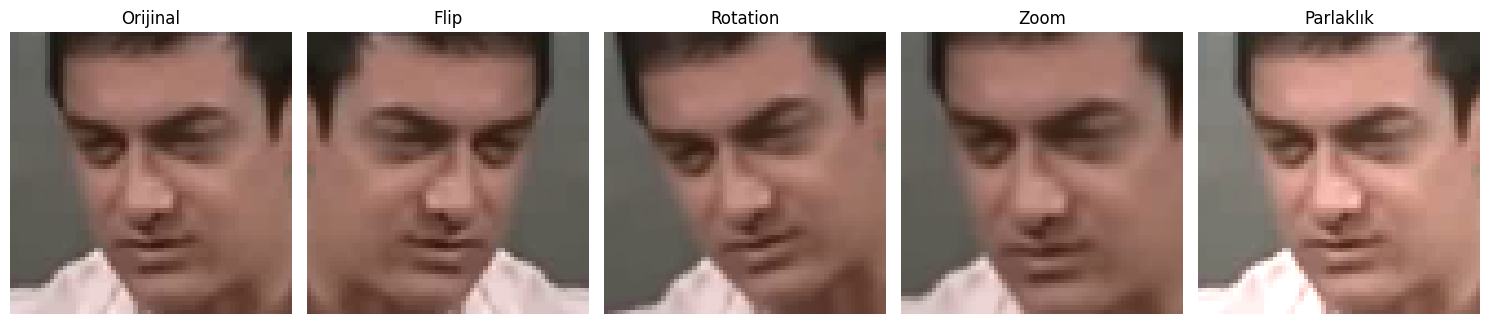

In [10]:
import matplotlib.pyplot as plt

# 1. Adım: Kareyi al
frames = video_to_frames("C:/Users/ENES/Desktop/proje/data/videos/id0_0001.mp4")

if len(frames) > 0:
    # 2. Adım: Yüzü tespit et
    faces = detect_and_crop_faces(frames[0])
    
    if len(faces) > 0:
        original_face = faces[0]
        
        # 3. Adım: Augmentasyon yap (Önceki adımda 5 versiyona çıkarmıştık)
        augmented = augment_image(original_face)
        # Başlık sayısını fonksiyonun döndürdüğü liste uzunluğuna göre ayarla
        titles = ["Orijinal", "Flip", "Rotation", "Zoom", "Parlaklık"]

        # 4. Adım: Görselleştir
        plt.figure(figsize=(15, 5))
        for i, img in enumerate(augmented):
            plt.subplot(1, len(augmented), i+1)
            
            # Görüntü zaten RGB olduğu için doğrudan bastırıyoruz
            plt.imshow(img)
            
            if i < len(titles):
                plt.title(titles[i])
            plt.axis('off')
            
        plt.tight_layout()
        plt.show()
    else:
        print("Uyarı: Bu karede yüz tespit edilemedi.")
else:
    print("Hata: Video dosyası okunamadı veya kare bulunamadı.")

In [11]:
# def load_data_from_json(json_path, video_folder):
#     with open(json_path, 'r') as f:
#         data_info = json.load(f)

#     data = []
#     labels = []


#     for item in data_info:
#         video_path = os.path.join(video_folder, item['video_name'])
#         cap = cv2.VideoCapture(video_path)

#         success, frame = cap.read()

#         while success:
#             frame = cv2.resize(frame, (64, 64)) / 255.0

#             # AUGMENTATION
#             augmented_list = augment_image(frame)

#             for aug_img in augmented_list:
#                 data.append(aug_img)
#                 labels.append(item['label'])

#             success, frame = cap.read()

#         cap.release()

#     return np.array(data), np.array(labels)


# Bu 3x3 blok, bir resim pikseli alt-matrisi (patch) ve değerler RGB kanalının normalize edilmiş değerleri.
#load_data_from_json("C:/Users/ENES/Desktop/proje/data_info.json", "C:/Users/ENES/Desktop/proje/data/videos")


In [12]:
# def load_data_from_json_optimized(metadata_subset, video_folder, is_training=True):
#     """
#     metadata_subset: train_test_split ile ayrılmış JSON alt kümesi
#     is_training: Eğer True ise Augmentation yapar, False ise (Test seti) yapmaz.
#     """
#     data = []
#     labels = []

#     for item in metadata_subset:
#         video_path = os.path.join(video_folder, item['video_name'])
        
#         # Daha önce yazdığımız video_to_frames fonksiyonunu kullanıyoruz (Atlamalı okuma yapar)
#         # max_frames=15 seçerek her videodan sınırlı veri alıyoruz
#         frames = video_to_frames(video_path, max_frames=15) 

#         for frame in frames:
#             # 1. Yüzü Tespit Et ve Kırp
#             faces = detect_and_crop_faces(frame)
            
#             if len(faces) > 0:
#                 face = faces[0] / 255.0 # Normalize et
                
#                 # 2. Sadece EĞİTİM setindeysek Augmentation yap
#                 if is_training:
#                     augmented_list = augment_image(face)
#                     for aug_img in augmented_list:
#                         data.append(aug_img)
#                         labels.append(item['label'])
#                 else:
#                     # Test seti orijinal kalmalı (gerçekçi ölçüm için)
#                     data.append(face)
#                     labels.append(item['label'])
                    
#     return np.array(data, dtype='float32'), np.array(labels, dtype='int32')

In [13]:
# def load_data_from_json_optimized(json_path_or_list, video_folder, is_training=True):
#     # Eğer gelen şey bir dosya yolu (string) ise dosyayı aç ve oku
#     if isinstance(json_path_or_list, str):
#         with open(json_path_or_list, 'r', encoding='utf-8') as f:
#             metadata_subset = json.load(f)
#     else:
#         # Eğer zaten train_test_split'ten gelen bir listeyse direkt kullan
#         metadata_subset = json_path_or_list

#     data = []
#     labels = []

#     for item in metadata_subset:
#         video_name = item['video_name']
#         label = item['label']
#         video_path = os.path.join(video_folder, video_name)
        
#         # Kareleri al
#         frames = video_to_frames(video_path, max_frames=15)
        
#         for frame in frames:
#             faces = detect_and_crop_faces(frame)
#             if len(faces) > 0:
#                 face = faces[0] / 255.0
#                 if is_training:
#                     augmented_list = augment_image(face)
#                     for aug_img in augmented_list:
#                         data.append(aug_img)
#                         labels.append(label)
#                 else:
#                     data.append(face)
#                     labels.append(label)
                    
#     return np.array(data, dtype='float32'), np.array(labels, dtype='int32')

In [14]:
def load_data_from_json_optimized(json_path_or_list, video_folder, is_training=True):
    if isinstance(json_path_or_list, str):
        with open(json_path_or_list, 'r', encoding='utf-8') as f:
            metadata_subset = json.load(f)
    else:
        metadata_subset = json_path_or_list

    data = []
    labels = []

    for item in metadata_subset:
        video_name = item['video_name']
        label = item['label']
        video_path = os.path.join(video_folder, video_name)
        
        frames = video_to_frames(video_path, max_frames=10) # Her videodan sınırlı sayıda kare alarak veri setini dengeleriz
        
        for frame in frames:
            faces = detect_and_crop_faces(frame)
            if len(faces) > 0:
                # ÖNCE Normalize et (0-1 arasına çek)
                face = faces[0].astype('float32') / 255.0
                
                if is_training:
                    # Eğitim setinde veriyi çoğalt
                    augmented_list = augment_image(face)
                    for aug_img in augmented_list:
                        data.append(aug_img)
                        labels.append(label)
                else:
                    # Test setinde sadece orijinal yüzü ekle
                    data.append(face)
                    labels.append(label)
    
    # Listeleri numpy dizisine çevir
    X = np.array(data, dtype='float32')
    y = np.array(labels, dtype='int32')

    # --- KRİTİK EKLEME: Karıştırma (Shuffle) ---
    # Veri setini karıştırarak modelin "aynı videoya takılı kalmasını" engelliyoruz
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]
                    
    return X, y


# neden np.random.shuffle kullanıyoruz? Çünkü veriler genellikle videoya göre sıralıdır ve 
# modelin sırayla aynı videolara bakarak öğrenmesini istemeyiz.
# Karıştırma, modelin farklı videolardan gelen örnekleri görmesini sağlar ve genelleme yeteneğini artırır.

In [15]:
import json
import numpy as np
from sklearn.model_selection import train_test_split

#-------------------------
# Global değişkenler (Eğer daha önce tanımlanmışlarsa temizlenir)
x_train, y_train, x_test, y_test = None, None, None, None

# 1. Adım: JSON dosyasını oku
json_yolu = 'C:/Users/ENES/Desktop/proje/data_info.json'
video_klasoru = 'C:/Users/ENES/Desktop/proje/data/videos'

with open(json_yolu, 'r', encoding='utf-8') as f:
    tum_metadata = json.load(f)

# 2. Adım: Önce VİDEOLARI bölüyoruz (Data Leakage engellemek için)
# 10 videonun 8'i eğitime, 2'si teste gidecek şekilde ayırıyoruz
train_meta, test_meta = train_test_split(
    tum_metadata, 
    test_size=0.2, 
    random_state=42, 
    stratify=[item['label'] for item in tum_metadata] # Gerçek/Sahte oranını koru
)

print(f"Eğitim için {len(train_meta)} video, Test için {len(test_meta)} video seçildi.")


#---------------------------------
# Veri yükleme adımından hemen önce eski verileri temizlemek bilgisayarı rahatlatır
import gc
if 'x_train' in locals():
    print("Eski veriler bellekten temizleniyor...")
    del x_train, y_train, x_test, y_test
    gc.collect()

# 3. Adım: Optimize edilmiş fonksiyonla verileri yükle
print("Eğitim verileri hazırlanıyor (Augmentation uygulanıyor)...")
x_train, y_train = load_data_from_json_optimized(train_meta, video_klasoru, is_training=True)

print("Test verileri hazırlanıyor (Orijinal kareler)...")
x_test, y_test = load_data_from_json_optimized(test_meta, video_klasoru, is_training=False)

print("\n--- Yükleme Tamamlandı ---")
print(f"x_train boyutu: {x_train.shape} | y_train boyutu: {y_train.shape}")
print(f"x_test boyutu: {x_test.shape}   | y_test boyutu: {y_test.shape}")

Eğitim için 8 video, Test için 2 video seçildi.
Eski veriler bellekten temizleniyor...
Eğitim verileri hazırlanıyor (Augmentation uygulanıyor)...
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyut

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_cnn_model():
    model = Sequential([
        # Girdi katmanı
        Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        BatchNormalization(), # Eğitimi hızlandırır ve daha kararlı hale getirir.
        MaxPooling2D((2, 2)),
        
        # Daha derin özellikler için 2. katman
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # 3. Katman (Modelin öğrenme kapasitesini artırır)
        #Conv2D(128, (3, 3), activation='relu'),
        #BatchNormalization(),
        #MaxPooling2D((2, 2)),

        Flatten(),
        # global average pooling gibi daha gelişmiş bir yöntem de kullanılabilir, 
        # bu, parametre sayısını ciddi oranda azaltır.
        # ama şu anki veri setiyle Flatten ile devam etmekde hiçbir sakınca yok.
        
        
        # l2(0.01) değeri cezalandırma miktarını belirler. 
        # Eğer hala ezberliyorsa 0.01 yap, eğer çok yavaş öğreniyorsa 0.001 yap.
        Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.01)), # L2 regularization ile ağırlıkların çok büyümesini engeller.
        # Ezberlemeyi önleyen Dropout katmanı
        Dropout(0.7), # Modelin sadece belirli piksellere veya kişiye odaklanmasını engeller. Her adımda farklı nöronları kullanarak genel özellikleri öğrenmeye zorlar.
        
        Dense(1, activation='sigmoid')
    ])

    # Modeli derlememiz (compile) gerekiyor:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Daha düşük öğrenme hızı, modelin veriyi çok hızlı ezberlemesini önler, daha yavaş ve emin adımlarla öğrenmesini sağlar.
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    return model

# Keras'ta ağırlık cezalandırması (Weight Regularization), modelin öğrenirken katsayılarını (weights) çok büyütmesini engeller. Katsayılar çok büyüdüğünde model verideki gürültüyü ezberlemeye başlar. Biz buna L2 Regularization (veya Ridge) diyoruz.

# Deepfake projelerinde az veriyle çalışırken bu yöntem hayat kurtarıcı olabilir çünkü modeli "basit kalmaya" zorlar.

# Dense katmanına kernel_regularizer parametresini ekleyerek bunu yapabiliriz


# def create_cnn_model():
#     # Sequential modeli oluşturulur
#     model = Sequential([
#         # İlk evrişim katmanı, 32 filtre ve (3, 3) çekirdek boyutu ile; girdi boyutu (64, 64, 3)
#         Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
#         # Maksimum havuzlama katmanı, (2, 2) boyutunda
#         MaxPooling2D((2, 2)),
#         # İkinci evrişim katmanı, 64 filtre ve (3, 3) çekirdek boyutu ile
#         Conv2D(64, (3, 3), activation='relu'),
#         # İkinci maksimum havuzlama katmanı
#         MaxPooling2D((2, 2)),
#         # Katmanları tek boyutlu bir vektöre düzleştirir
#         Flatten(),
#         # Tam bağlantılı katman, 64 nöron ve ReLU aktivasyon fonksiyonu ile
#         Dense(64, activation='relu'),
#         # Çıkış katmanı, 1 nöron ve sigmoid aktivasyon fonksiyonu ile
#         Dense(1, activation='sigmoid')
#     ])

#     # Modeli Adam optimizasyon algoritması ve binary cross-entropy kaybı ile derler
#     adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # Modelin veriyi çok hızlı ezberlemesini önler,
#                                                                    daha yavaş ve emin adımlarla öğrenmesini sağlar.
#     model.compile(optimizer=adam_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
#     return model

In [17]:
# def train_model(json_path, video_folder):
#     # JSON dosyasından ve video klasöründen verileri yükledik
#     data, labels = load_data_from_json(json_path, video_folder)  

#     # Veriyi eğitim ve test setlerine ayırdık
#     x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.5, shuffle=True, random_state=42)

#     # Model checkpoint callback
#     checkpoint_path = "model_checkpoint.keras"  # Checkpoint dosyasının yolu
#     checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')  # En iyi doğruluk değeri için checkpoint

#     # Eğer checkpoint olarak .keras dosyası var ise yükle, yoksa yeni model oluştur
#     if os.path.exists(checkpoint_path):
#         model = load_model(checkpoint_path)  # Var olan checkpoint dosyasını yükledik
#         print("Checkpoint yüklendi.")
#     else:
#         model = create_cnn_model()  # Yeni bir model oluşturur
#         # Modeli eğitim verisi ile eğitir
#         model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), callbacks=[checkpoint])  
#         print("Yeni model oluşturuldu.")

#     return model, x_test, y_test  # Eğitilmiş modeli ve test verilerini döndürür

In [18]:
import numpy as np
import json
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Train: Öğrenmek için.

# Validation: Eğitim sırasında parametreleri ayarlamak ve overfitting'i kontrol etmek için.

# Test: Modelin daha önce hiç görmediği verideki gerçek performansını ölçmek için.

# data leakage var 
# def train_model(json_path, video_folder):
#     data, labels = load_data_from_json(json_path, video_folder)
    
#     # 1. Adım: Verinin %20'sini tamamen kenara ayır (Gerçek TEST seti)
#     x_train_val, x_test, y_train_val, y_test = train_test_split(
#         data, labels, test_size=0.2, random_state=42, stratify=labels
#     )
    
#     # 2. Adım: Kalanın %20'sini Doğrulama (VALIDATION) seti yap
#     x_train, x_val, y_train, y_val = train_test_split(
#         x_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
#     )

#     checkpoint_path = "model_checkpoint.keras"
#     checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1)
    
#     # Sabır (patience) parametresi: val_loss 3 epoch boyunca iyileşmezse durdur.
#     early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#     model = create_cnn_model()
#     history = model.fit(
#         x_train, y_train,
#         epochs=20, # Dropout olduğu için epoch sayısını biraz artırabilirsin
#         validation_data=(x_val, y_val), # Artık ayrı bir doğrulama setimiz var
#         callbacks=[checkpoint, early_stop]
#     )

#     return model, history, x_test, y_test

# def train_model(json_path, video_folder):
#     data, labels = load_data_from_json(json_path, video_folder)
#     x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.5, random_state=42, shuffle=True, stratify=labels)

#     checkpoint_path = "model_checkpoint.keras"
#     checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

#     if os.path.exists(checkpoint_path):
#         model = load_model(checkpoint_path)
#         print("Checkpoint yüklendi.")
#         history = None
#     else:
#         model = create_cnn_model()
#         history = model.fit(
#             x_train, y_train,
#             epochs=10,
#             validation_data=(x_test, y_test),
#             callbacks=[checkpoint]
#         )
#         print("Yeni model oluşturuldu.")

#     return model, history, x_test, y_test


#optimize
def train_model(json_path, video_folder):
    # 1. Önce sadece JSON'daki video listesini oku (Görüntüleri henüz yükleme)
    with open(json_path, 'r') as f:
        metadata = json.load(f)
    
    # 2. Önce VİDEO isimlerini böl (Bu sayede bir video ya train'dedir ya test'te)
    # Strateji: Video bazlı bölünme Data Leakage'ı sıfırlar.
    labels_for_stratify = [item['label'] for item in metadata]
    train_val_meta, test_meta = train_test_split(
        metadata, test_size=0.2, random_state=42, stratify=labels_for_stratify
    )
    
    # 3. Şimdi görüntüleri yükle 
    # Not: Bu aşamada is_training=True/False vererek sadece eğitime Augmentation yapabiliriz.
    print("Eğitim verileri yükleniyor...")
    x_train_val, y_train_val = load_data_from_json_optimized(train_val_meta, video_folder, is_training=True)
    
    print("Test verileri yükleniyor...")
    x_test, y_test = load_data_from_json_optimized(test_meta, video_folder, is_training=False)

    # 4. Train_Val'i kendi içinde böl (Validation seti için)
    x_train, x_val, y_train, y_val = train_test_split(
        x_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
    )

    # Callback'leri tanımla
    checkpoint = ModelCheckpoint("model_checkpoint.keras", monitor='val_loss', save_best_only=True, mode='min')
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # Modeli oluştur ve eğit
    model = create_cnn_model()
    history = model.fit(
        x_train, y_train,
        epochs=20,
        validation_data=(x_val, y_val),
        class_weight={0: 2.0, 1: 1.0}, # 0 sınıfına (Real) 2 kat daha fazla önem ver!
        callbacks=[checkpoint, early_stop],
        batch_size=32 # Batch size eklemek stabiliteyi artırır
    )
    print("Eğitim tamamlandı. En iyi model kaydedildi.")
    
    return model, history, x_test, y_test


# Neleri Doğru Yaptım?
#Data Leakage Engellendi: metadata üzerinden bölme yaparak modelin aynı kişiyi hem eğitimde hem teste görmesini imkansız hale getirdim.
#3'lü Ayrım: Veriyi sadece Train ve Test değil; Train, Validation ve Test olarak üçe ayırdım. Bu, modelin başarısını tarafsız bir şekilde ölçmek için en doğru yöntemdir.
#Callback'ler: EarlyStopping ve ModelCheckpoint kullanarak modelin en iyi halini (best weights) korumasını sağladım. patience=3 değeri de oldukça makul.
#Stratify: Etiket oranlarını her iki sette de korudum.

In [19]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Tüm GPU'ları kullan
        for gpu in gpus:
            # GPU bellek büyümesini etkinleştir
            tf.config.experimental.set_memory_growth(gpu, True)
        # Mantıksal GPU'ların listesini al
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        # Fiziksel ve mantıksal GPU sayısını yazdır
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Hatayı yazdır
        print(e)

In [20]:
import os

yol = 'C:/Users/ENES/Desktop/proje/data_info.json'
if os.path.exists(yol):
    print("Dosya bulundu!")
else:
    print("Dosya hala bulunamadı, lütfen yolu kontrol edin.")

Dosya bulundu!


In [21]:
# from sklearn.model_selection import train_test_split

# model, history, x_test, y_test = train_model(
#     'C:/Users/ENES/Desktop/proje/data_info.json',
#     'C:/Users/ENES/Desktop/proje/data/videos'
# )

# Fonksiyonu çağırıyoruz
model, history, x_test, y_test = train_model(
    'C:/Users/ENES/Desktop/proje/data_info.json',
    'C:/Users/ENES/Desktop/proje/data/videos'
)

print("\nModel Özeti:",model.summary())


#Precision, "Fake" dediği videoların ne kadarı gerçekten sahte?
#Recall, Gerçekten sahte olan videoların yüzde kaçını yakalayabildi?
#F1-Score, Modelin genel "sağlık" puanı.

Eğitim verileri yükleniyor...
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görü

c:\Users\ENES\Desktop\proje\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5719 - loss: 10.9843 - val_accuracy: 0.5000 - val_loss: 3.3210
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5875 - loss: 7.7350 - val_accuracy: 0.6375 - val_loss: 5.1315
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.6281 - loss: 7.9178 - val_accuracy: 0.5000 - val_loss: 5.0669
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6187 - loss: 6.3490 - val_accuracy: 0.5000 - val_loss: 4.9135
Eğitim tamamlandı. En iyi model kaydedildi.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,876,613 (18.60 MB)

 Trainable params: 1,625,473 (6.20 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 3,250,948 (12.40 MB)


Model Özeti: None


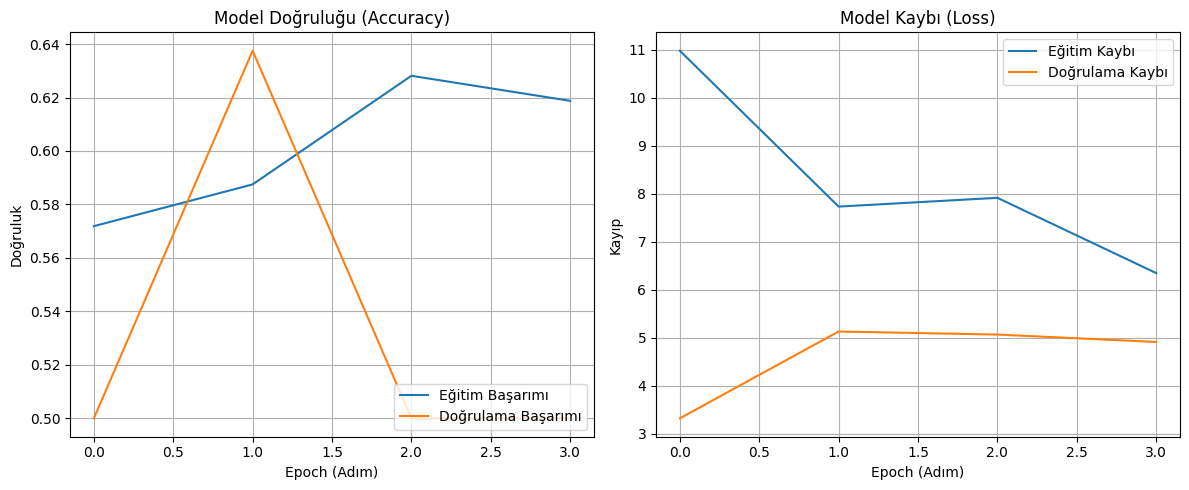

In [22]:
import matplotlib.pyplot as plt

if history is not None and hasattr(history, 'history'):
    # İki yan yana grafik için alan oluştur (1 satır, 2 sütun)
    plt.figure(figsize=(12, 5))

    # 1. Grafik: Accuracy (Doğruluk)
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get('accuracy', history.history.get('acc', [])), label='Eğitim Başarımı')
    plt.plot(history.history.get('val_accuracy', history.history.get('val_acc', [])), label='Doğrulama Başarımı')
    plt.title('Model Doğruluğu (Accuracy)')
    plt.xlabel('Epoch (Adım)')
    plt.ylabel('Doğruluk')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Grafik: Loss (Kayıp)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Eğitim Kaybı')
    plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
    plt.title('Model Kaybı (Loss)')
    plt.xlabel('Epoch (Adım)')
    plt.ylabel('Kayıp')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Grafik çizilemedi: Model checkpoint'ten yüklendi veya eğitim geçmişi bulunamadı.")

In [23]:
# from sklearn.metrics import classification_report
# import numpy as np
# import matplotlib.pyplot as plt

# def evaluate_model(model, history, x_test, y_test):
#     # 1) Eğitim ilerleme grafiği (history varsa)
#     if history is not None:
#         plt.figure(figsize=(10, 4))
#         plt.subplot(1, 2, 1)
#         plt.plot(history.history.get('loss', []), label='train_loss')
#         plt.plot(history.history.get('val_loss', []), label='val_loss')
#         plt.legend()
#         plt.title('Loss')
#         plt.subplot(1, 2, 2)
#         plt.plot(history.history.get('accuracy', []), label='train_acc')
#         plt.plot(history.history.get('val_accuracy', []), label='val_acc')
#         plt.legend()
#         plt.title('Accuracy')
#         plt.tight_layout()
#         plt.show()
#     else:
#         print("history None: checkpointten model yüklendi veya eğitim atlandı.")

#     # 2) Test tahmini ve sınıf raporu
#     preds = (model.predict(x_test) > 0.5).astype("int32").flatten()

#     classes = np.unique(np.concatenate([y_test, preds]))
#     class_names = ['REAL' if c == 1 else 'FAKE' for c in classes]

#     print(classification_report(
#         y_test,
#         preds,
#         labels=classes,
#         target_names=class_names,
#         zero_division=0
#     ))

# # Çağırma
# evaluate_model(model, history, x_test, y_test)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # Görselleştirme için ekleyebiliriz
import matplotlib.pyplot as plt

def evaluate_model(model, history, x_test, y_test):
    # 1) Eğitim ilerleme grafiği
    if history is not None and hasattr(history, 'history'):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history.get('loss', []), label='Eğitim Kaybı')
        plt.plot(history.history.get('val_loss', []), label='Doğrulama Kaybı')
        plt.legend()
        plt.title('Kayıp (Loss)')
        
        plt.subplot(1, 2, 2)
        plt.plot(history.history.get('accuracy', []), label='Eğitim Başarımı')
        plt.plot(history.history.get('val_accuracy', []), label='Doğrulama Başarımı')
        plt.legend()
        plt.title('Başarım (Accuracy)')
        plt.tight_layout()
        plt.show()
    else:
        print("Grafik çizilemedi: Eğitim geçmişi (history) bulunamadı.")

    # 2) Test tahmini
    # Model çıktısı 0.5'ten büyükse 1 (Fake), küçükse 0 (Real)
    preds = (model.predict(x_test) > 0.5).astype("int32").flatten()

    # 3) Sınıf İsimlerini Sabitleme
    # Sizin yapınıza göre: 0 -> REAL, 1 -> FAKE

    target_names = ['REAL', 'FAKE']

    print("\n--- Sınıflandırma Raporu ---")
    print(classification_report(
        y_test, 
        preds, 
        target_names=target_names,
        zero_division=0
    ))

    # Opsiyonel: Karmaşıklık Matrisi (Confusion Matrix)
    # Hangi sınıfın hangisiyle karıştırıldığını daha net görmek için:
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek Değer')
    plt.title('Karmaşıklık Matrisi')
    plt.show()


# Modelin yapısını kontrol et
print("\nModel Özeti:",model.summary())

# Modeli değerlendir
# x_test artık modelin "hayatında hiç görmediği" videolardan oluşuyor!
# Modeli çağırma
#evaluate_model(model, history, x_test, y_test)

#------------------------
print("\nModelin Test Seti Performansı:")
# Tahminleri al
y_pred_probs = model.predict(x_test)

# Eşiği 0.5 yerine kendi ortalaman olan 0.68 veya biraz üzerine çek
# Böylece modelin "en az şüpheli" bulduğu videolar REAL olarak işaretlenir
custom_threshold = 0.30 
y_pred_final = (y_pred_probs > custom_threshold).astype(int)

# Şimdi raporu tekrar al
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_final))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,876,613 (18.60 MB)

 Trainable params: 1,625,473 (6.20 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 3,250,948 (12.40 MB)


Model Özeti: None

Modelin Test Seti Performansı:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



c:\Users\ENES\Desktop\proje\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ENES\Desktop\proje\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ENES\Desktop\proje\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
import numpy as np
print(np.unique(y_test, return_counts=True))

(array([0, 1], dtype=int32), array([10, 10]))


In [26]:
def evaluate_model(model,x_test,y_test):
    # Modeli test verisi üzerinde değerlendir
    predictions=(model.predict(x_test)>0.5).astype("int32")  # Tahminleri ikili sınıflara dönüştür
    print(classification_report(y_test, predictions,target_names=['REAL', 'FAKE']))  # Sınıflandırma

evaluate_model(model,x_test,y_test)  # Modeli değerlendir   

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
              precision    recall  f1-score   support

        REAL       0.50      1.00      0.67        10
        FAKE       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



c:\Users\ENES\Desktop\proje\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ENES\Desktop\proje\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ENES\Desktop\proje\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
# 1. JSON'u önce kendimiz okuyoruz
json_yolu = "C:/Users/ENES/Desktop/proje/data_info.json"
video_klasoru = "C:/Users/ENES/Desktop/proje/data/videos"

with open(json_yolu, 'r', encoding='utf-8') as f:
    json_verisi = json.load(f)

# 2. Şimdi fonksiyona yolu değil, okuduğumuz listeyi gönderiyoruz
data, labels = load_data_from_json_optimized(
    json_verisi, # Burası artık string değil, bir liste!
    video_klasoru,
    is_training=True
)

print("Veri yüklendi!")
print("X Boyutu:", data.shape)
print("Sınıf Dağılımı:", np.unique(labels, return_counts=True))

Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (5

In [28]:
_, _, _, y_test = train_model(
    "C:/Users/ENES/Desktop/proje/data_info.json",
    "C:/Users/ENES/Desktop/proje/data/videos"
)
print("y_test balance:", np.unique(y_test, return_counts=True))

Eğitim verileri yükleniyor...
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 944, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görüntü tipi: uint8, boyutları: (500, 942, 3)
Toplam 1 yüz çıkarıldı
Görü

c:\Users\ENES\Desktop\proje\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5219 - loss: 10.9175 - val_accuracy: 0.5000 - val_loss: 7.5121
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6000 - loss: 9.9964 - val_accuracy: 0.6250 - val_loss: 4.0834
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6062 - loss: 9.0765 - val_accuracy: 0.5625 - val_loss: 3.2622
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6313 - loss: 8.5978 - val_accuracy: 0.5625 - val_loss: 4.8946
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6562 - loss: 8.4379 - val_accuracy: 0.5625 - val_loss: 4.1160
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6156 - loss: 7.2518 - val_accuracy: 0.5625 - val_loss: 4.0612
Eğitim tamamlandı. En iyi model kaydedildi.
y_test balance: (array([0, 1], dtype=int32), array([10, 10]))


In [29]:
import json
with open("C:/Users/ENES/Desktop/proje/data_info.json", "r", encoding="utf-8") as f:
    info = json.load(f)

from collections import Counter
print(Counter([item['label'] for item in info]))

Counter({0: 5, 1: 5})


In [30]:
predictions = model.predict(x_test)
print("Tahminlerin ortalaması:", np.mean(predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Tahminlerin ortalaması: 0.46937418


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


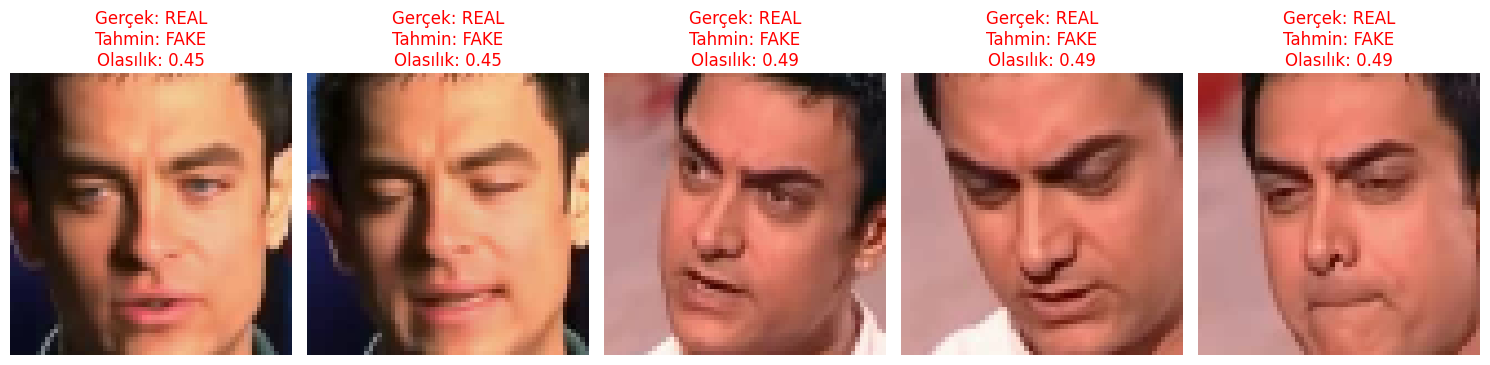

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_errors(model, x_test, y_test, threshold=0.5, num_images=5):
    # 1. Modelden olasılık tahminlerini al
    y_pred_probs = model.predict(x_test).flatten()
    y_pred = (y_pred_probs > threshold).astype(int)
    
    # 2. Hatalı tahminlerin indekslerini bul
    # (Tahmin edilen etiket gerçek etiketten farklıysa)
    error_indices = np.where(y_pred != y_test)[0]
    
    if len(error_indices) == 0:
        print("Tebrikler! Model test setinde hiç hata yapmadı.")
        return

    # Görselleştirilecek miktar kadar indeks seç (en fazla num_images kadar)
    n = min(len(error_indices), num_images)
    selected_indices = error_indices[:n]

    plt.figure(figsize=(15, 5))
    
    for i, idx in enumerate(selected_indices):
        plt.subplot(1, n, i + 1)
        
        # Görüntüyü göster (Normalizasyonu geri almak için 255 ile çarpıyoruz)
        plt.imshow(x_test[idx]) 
        
        actual = "FAKE" if y_test[idx] == 1 else "REAL"
        predicted = "FAKE" if y_pred[idx] == 1 else "REAL"
        prob = y_pred_probs[idx]

        # Başlığı kırmızı yaparak hatayı vurgula
        plt.title(f"Gerçek: {actual}\nTahmin: {predicted}\nOlasılık: {prob:.2f}", color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Fonksiyonu çağır
visualize_errors(model, x_test, y_test, threshold=0.30, num_images=5)